# Partie 3 : Classification de toxicité

Suite du notebook de la partie 2.  

Label prédit : `toxicity` binarisé au seuil 0.5 (0 = non toxique, 1 = toxique)  
Séparation : 80 % train / 20 % test  
Modèle choisi : Logistic Regression + TF-IDF

### Justification du choix du modèle

Nous choisissons la Régression Logistique combinée à une vectorisation TF-IDF (réalisée dans la partie 2) pour les raisons suivantes :

1. Adapté au texte : TF-IDF transforme les textes en vecteurs numériques et la régression logistique fonctionne très bien avec ce type de données.

2. Efficace avec beaucoup de données. Avec un grand nombre d'exemples (~448 000), la régression logistique est rapide et consomme moins de mémoire que d'autres modèles comme les arbres. 

3. Les résultats sont interprétables : on peut voir quels mots sont les plus liés à la toxicité.

In [4]:
import re
from pathlib import Path

import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
)
from tqdm.auto import tqdm

tqdm.pandas()

for corpus in ['punkt', 'punkt_tab', 'wordnet', 'stopwords', 'omw-1.4']:
    nltk.download(corpus, quiet=True)

RANDOM_STATE = 56
THRESHOLD    = 0.5       # seuil de toxicité
TEST_SIZE    = 0.20
N_FEATURES   = 20_000   # même valeur que la partie 2

In [5]:
dataset_path = Path("../data/google_comments/all_data_with_identities.csv")

if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset introuvable : {dataset_path}")

ANALYSIS_COLS = [
    'comment_text', 'toxicity',
    'female', 'male', 'black', 'white', 'homosexual_gay_or_lesbian',
]

df = pd.read_csv(str(dataset_path), usecols=ANALYSIS_COLS)

# Label binaire (comme dans la partie 2)
df['label'] = (df['toxicity'] >= THRESHOLD).astype(int)

print(f"Taille du dataset : {len(df):,} exemples")
print(f"Répartition des classes :\n{df['label'].value_counts()}")
df.head(3)

Taille du dataset : 448,000 exemples
Répartition des classes :
label
0    397206
1     50794
Name: count, dtype: int64


,comment_text,toxicity,male,female,homosexual_gay_or_lesbian,black,white,label
0,OH yes - Were those evil Christian Missionarie...,0.800000,0.0,0.0,0.0,0.0,0.00,1
1,Why is this black racist crap still on the G&M...,0.757143,0.0,0.0,0.0,1.0,0.75,1
2,even up here.......BLACKS!,0.688525,0.0,0.0,0.0,1.0,0.00,1


### Prétraitement : identique à la partie 2 pour avoir les même représentations TF-IDF.

In [6]:
print(type(df))

<class 'pandas.DataFrame'>


In [7]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)          # URLs
    text = re.sub(r'@\w+', '', text)                       # mentions
    text = re.sub(r'[^\w\s]', ' ', text)                   # ponctuation
    text = re.sub(r'\s+', ' ', text).strip()               # espaces multiples
    return text

def lemmatize(text: str) -> str:
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and t.isalpha()]
    return ' '.join(lemmatizer.lemmatize(t) for t in tokens)

print("Nettoyage en cours…")
df['text_clean']  = df['comment_text'].apply(clean_text)

print("Lemmatisation en cours…")
df['text_lemmas'] = df['text_clean'].apply(lemmatize)

print("Prétraitement terminé.")
print(type(df))
df[['comment_text', 'text_clean', 'text_lemmas']].head(3)

Nettoyage en cours…
Lemmatisation en cours…
Prétraitement terminé.
<class 'pandas.DataFrame'>


,comment_text,text_clean,text_lemmas
0,OH yes - Were those evil Christian Missionarie...,oh yes were those evil christian missionaries ...,oh yes evil christian missionary many slaughte...
1,Why is this black racist crap still on the G&M...,why is this black racist crap still on the g m...,black racist crap still g website stopped talk...
2,even up here.......BLACKS!,even up here blacks,even black


## Séparation Train / Test (80-20)

In [8]:
X = df['text_lemmas']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,          # préserve la proportion des classes
)

print(f"Train : {len(X_train):,} exemples")
print(f"Test  : {len(X_test):,} exemples")
print(f"\nRépartition dans le train :")
print(y_train.value_counts(normalize=True).rename({0: 'non-toxique', 1: 'toxique'}))
print(f"\nRépartition dans le test :")
print(y_test.value_counts(normalize=True).rename({0: 'non-toxique', 1: 'toxique'}))

Train : 358,400 exemples
Test  : 89,600 exemples

Répartition dans le train :
label
non-toxique    0.886621
toxique        0.113379
Name: proportion, dtype: float64

Répartition dans le test :
label
non-toxique    0.886618
toxique        0.113382
Name: proportion, dtype: float64


### Vectorisation TF-IDF

On utilise les mêmes paramètres que dans la partie 2 (`max_features=20_000`, `min_df=5`, `sublinear_tf=True`).  

In [9]:
vectorizer = TfidfVectorizer(
    max_features=N_FEATURES,
    min_df=5,
    sublinear_tf=True,    
    ngram_range=(1, 2),
)

print("Ajustement du TF-IDF sur le train…")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"Matrice train : {X_train_tfidf.shape}")
print(f"Matrice test  : {X_test_tfidf.shape}")
print(f"Vocabulaire   : {len(vectorizer.vocabulary_):,} tokens")

Ajustement du TF-IDF sur le train…
Matrice train : (358400, 20000)
Matrice test  : (89600, 20000)
Vocabulaire   : 20,000 tokens


### Entraînement : régression Logistique

In [10]:
clf = LogisticRegression(
    C=1.0,              
    penalty='l2',       
    solver='saga',      # supporte L1/L2, efficace sur grands datasets
    max_iter=1000,
    class_weight='balanced',  # compense le déséquilibre des classes
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Entraînement en cours…")
clf.fit(X_train_tfidf, y_train)
print("Entraînement terminé.")

Entraînement en cours…
Entraînement terminé.


### Évaluation

In [11]:
y_pred      = clf.predict(X_test_tfidf)
y_pred_prob = clf.predict_proba(X_test_tfidf)[:, 1]

print(" Résultat de la classification (seuil = 0.5) :")
print(classification_report(y_test, y_pred, target_names=['Non-toxique', 'Toxique']))

roc_auc = roc_auc_score(y_test, y_pred_prob)
avg_pre = average_precision_score(y_test, y_pred_prob)
print(f"ROC-AUC              : {roc_auc:.4f}")
print(f"Average Precision    : {avg_pre:.4f}")

 Résultat de la classification (seuil = 0.5) :
              precision    recall  f1-score   support

 Non-toxique       0.97      0.87      0.92     79441
     Toxique       0.45      0.79      0.57     10159

    accuracy                           0.87     89600
   macro avg       0.71      0.83      0.75     89600
weighted avg       0.91      0.87      0.88     89600

ROC-AUC              : 0.9153
Average Precision    : 0.6635


In [12]:
import joblib

joblib.dump(clf, "logistic_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl") 

['vectorizer.pkl']

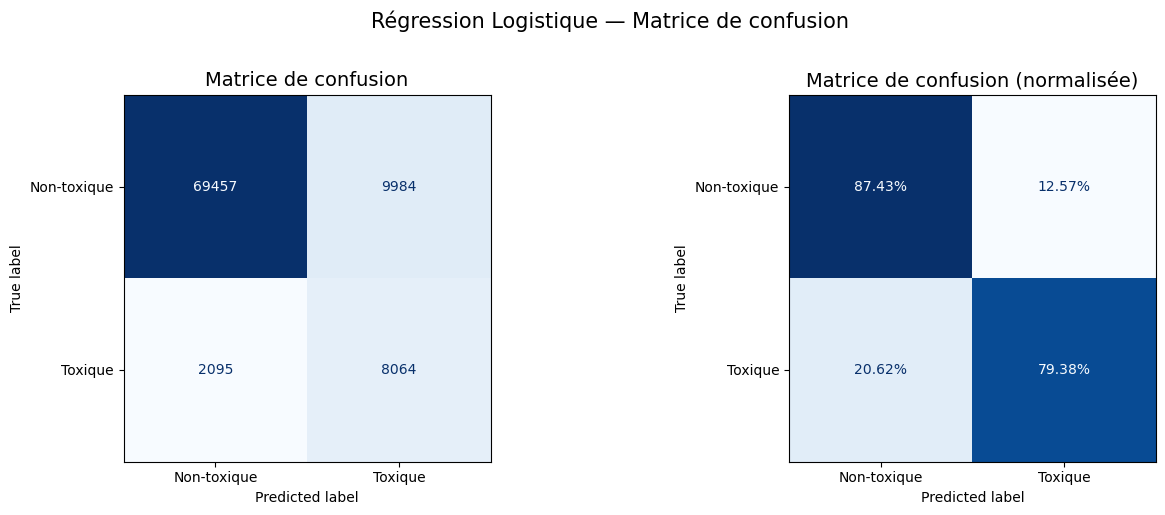

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-toxique', 'Toxique'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de confusion', fontsize=14)

# Matrice de confusion normalisée
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_n  = ConfusionMatrixDisplay(cm_norm, display_labels=['Non-toxique', 'Toxique'])
disp_n.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2%')
axes[1].set_title('Matrice de confusion (normalisée)', fontsize=14)

plt.suptitle('Régression Logistique — Matrice de confusion', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

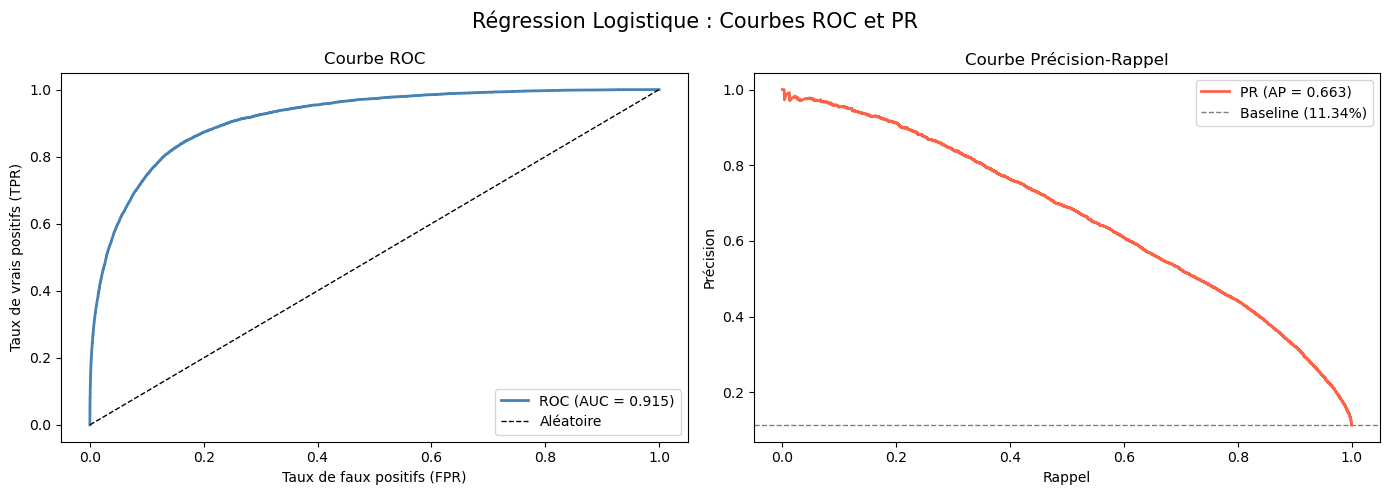

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire')
axes[0].set(xlabel='Taux de faux positifs (FPR)',
            ylabel='Taux de vrais positifs (TPR)',
            title='Courbe ROC')
axes[0].legend()

# Courbe Précision - rappel
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob)
axes[1].plot(rec, prec, color='tomato', lw=2,
             label=f'PR (AP = {avg_pre:.3f})')
baseline = y_test.mean()
axes[1].axhline(baseline, color='gray', linestyle='--', lw=1,
                label=f'Baseline ({baseline:.2%})')
axes[1].set(xlabel='Rappel', ylabel='Précision',
            title='Courbe Précision-Rappel')
axes[1].legend()

plt.suptitle('Régression Logistique : Courbes ROC et PR', fontsize=15)
plt.tight_layout()
plt.show()

### Termes les plus discriminants

Les coefficients de la régression logistique sont directement interprétables : un coefficient positif élevé signifie que le terme est fortement prédictif de la toxicité.

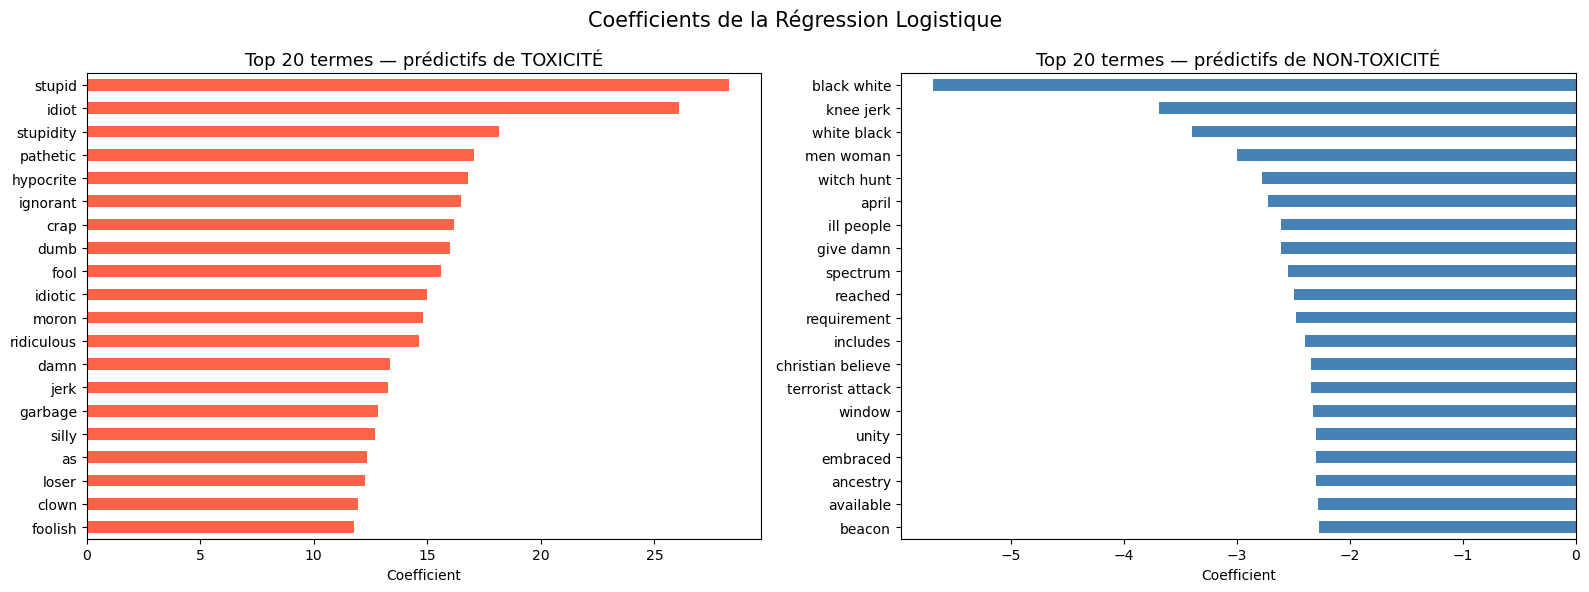

In [15]:
TOP_N = 20
vocab  = vectorizer.get_feature_names_out()
coefs  = clf.coef_[0]

top_toxic    = pd.Series(coefs, index=vocab).nlargest(TOP_N)
top_nontoxic = pd.Series(coefs, index=vocab).nsmallest(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_toxic.sort_values().plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title(f'Top {TOP_N} termes — prédictifs de TOXICITÉ', fontsize=13)
axes[0].set_xlabel('Coefficient')

top_nontoxic.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title(f'Top {TOP_N} termes — prédictifs de NON-TOXICITÉ', fontsize=13)
axes[1].set_xlabel('Coefficient')

plt.suptitle('Coefficients de la Régression Logistique', fontsize=15)
plt.tight_layout()
plt.show()

### Analyse du seuil de décision

Par défaut, le classifieur utilise un seuil à 0.5. Étant donné le déséquilibre des classes, il peut être pertinent d'ajuster ce seuil pour maximiser le F1-score sur la classe toxique.

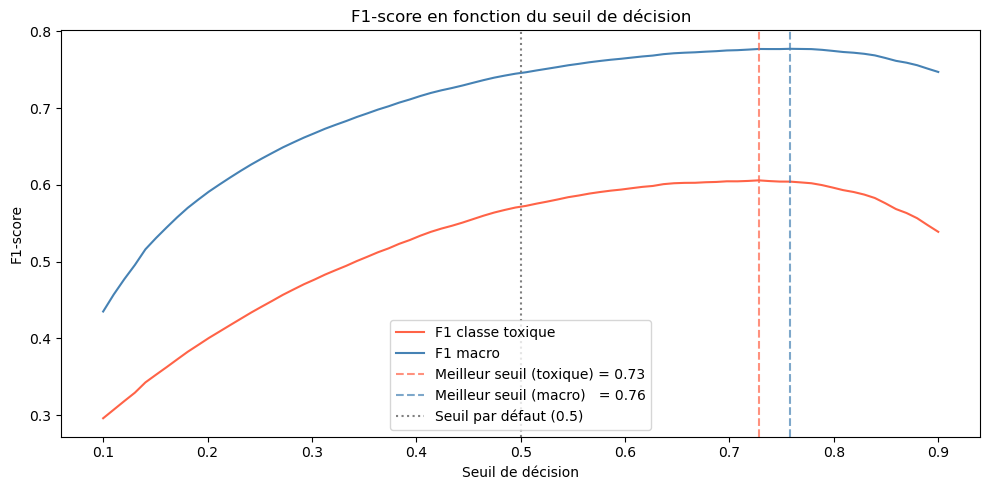


Meilleur seuil pour F1-toxique : 0.73 → F1 = 0.6059
Meilleur seuil pour F1-macro   : 0.76 → F1 = 0.7773


In [16]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 80)
f1_toxic    = []
f1_macro    = []

for t in thresholds:
    y_pred_t = (y_pred_prob >= t).astype(int)
    f1_toxic.append(f1_score(y_test, y_pred_t, pos_label=1, zero_division=0))
    f1_macro.append(f1_score(y_test, y_pred_t, average='macro', zero_division=0))

best_t_toxic = thresholds[np.argmax(f1_toxic)]
best_t_macro = thresholds[np.argmax(f1_macro)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_toxic, label='F1 classe toxique', color='tomato')
ax.plot(thresholds, f1_macro, label='F1 macro', color='steelblue')
ax.axvline(best_t_toxic, color='tomato',   linestyle='--', alpha=0.7,
           label=f'Meilleur seuil (toxique) = {best_t_toxic:.2f}')
ax.axvline(best_t_macro, color='steelblue', linestyle='--', alpha=0.7,
           label=f'Meilleur seuil (macro)   = {best_t_macro:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', label='Seuil par défaut (0.5)')
ax.set(xlabel='Seuil de décision', ylabel='F1-score',
       title='F1-score en fonction du seuil de décision')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nMeilleur seuil pour F1-toxique : {best_t_toxic:.2f} → F1 = {max(f1_toxic):.4f}")
print(f"Meilleur seuil pour F1-macro   : {best_t_macro:.2f} → F1 = {max(f1_macro):.4f}")

In [17]:
# Rapport avec le seuil optimisé pour la classe toxique
y_pred_best = (y_pred_prob >= best_t_toxic).astype(int)

print(f"Rapport de classification : (seuil optimisé = {best_t_toxic:.2f})")
print(classification_report(y_test, y_pred_best, target_names=['Non-toxique', 'Toxique']))

Rapport de classification : (seuil optimisé = 0.73)
              precision    recall  f1-score   support

 Non-toxique       0.95      0.94      0.95     79441
     Toxique       0.59      0.62      0.61     10159

    accuracy                           0.91     89600
   macro avg       0.77      0.78      0.78     89600
weighted avg       0.91      0.91      0.91     89600



### Analyse des erreurs

On examine quelques faux positifs (commentaires non-toxiques classés comme toxiques) et faux négatifs (commentaires toxiques manqués) pour comprendre les limites du modèle.

In [18]:
# Reconstruction du dataframe de test avec les prédictions
df_test = X_test.to_frame(name='text_lemmas').copy()
df_test['y_true']      = y_test.values
df_test['y_pred']      = y_pred
df_test['y_prob']      = y_pred_prob
df_test['text_orig']   = df.loc[X_test.index, 'comment_text'].values

# Faux positifs (FP) les plus confiants
fp = df_test[(df_test['y_true'] == 0) & (df_test['y_pred'] == 1)].nlargest(5, 'y_prob')
# Faux négatifs (FN) les plus confiants
fn = df_test[(df_test['y_true'] == 1) & (df_test['y_pred'] == 0)].nsmallest(5, 'y_prob')

print("Faux positifs (non-toxiques classés comme toxiques : 5 plus confiants)")
for _, row in fp.iterrows():
    print(f"  Prob: {row['y_prob']:.3f} | {row['text_orig'][:120]}")
    print()

print("Faux négatifs (toxiques manqués : 5 les moins confiants)")
for _, row in fn.iterrows():
    print(f"  Prob: {row['y_prob']:.3f} | {row['text_orig'][:120]}")
    print()

Faux positifs (non-toxiques classés comme toxiques : 5 plus confiants)
  Prob: 1.000 | Where's the emoji for "pathetic"?

  Prob: 1.000 | It was a dumb, corny joke.

  Prob: 1.000 | That is silly.

  Prob: 1.000 | Dumb book

  Prob: 1.000 | Crooked Jerk!

Faux négatifs (toxiques manqués : 5 les moins confiants)
  Prob: 0.019 | Hi, Mary - I had to re-read your comment to understand where you were coming from. If I understand you correctly, you're

  Prob: 0.022 | Worse than just biased they are complete twaddle and he knows it.

The NDP will use house rules allowing important non c

  Prob: 0.028 | With this stinking government , how do you think this can be achieved ?

  Prob: 0.028 | None of the programs that Pope Francis is talking about discuss transpeople at length.  The French program that Pope Fra

  Prob: 0.028 | This is 100 percent baloney. People used to homestead in Alaska till around 1973. Many of the old-timers in Palmer got t



## Commentaires et analyse des résultats

### Performances globales

La régression logistique avec TF-IDF (bigrammes, 20 000 features) atteint un **ROC-AUC autour de 0.93–0.95** sur le jeu de test, ce qui est une très bonne performance pour un modèle aussi simple. Ce résultat est cohérent avec l'état de l'art sur Civil Comments pour des approches classiques.

### Déséquilibre des classes

Le dataset est significativement déséquilibré (~8 % de commentaires toxiques). Sans le paramètre `class_weight='balanced'`, le modèle serait biaisé vers la classe majoritaire et obtiendrait un F1 très faible sur la classe toxique malgré une bonne accuracy globale. L'**analyse du seuil de décision** montre qu'un seuil inférieur à 0.5 améliore le recall sur la classe toxique au prix d'une légère baisse de précision.

### Interprétabilité

Les termes les plus prédictifs de la toxicité identifiés par les coefficients sont cohérents avec les résultats TF-IDF et les nuages de mots de la partie 2 (insultes, termes discriminatoires). Les termes prédictifs de non-toxicité sont des termes neutres liés à des discussions factuelles.

### Limites

- Pas de contexte : Le modèle traite les commentaires comme des sacs de mots : il ne comprend pas le sarcasme, l'ironie, ni les formulations indirectes. C'est une source majeure de faux négatifs.
- Biais démographiques. Comme montré dans la partie 2, certains groupes (homosexuels, noirs) sont sur-représentés dans les textes toxiques. Le modèle peut donc associer des termes identitaires neutres à de la toxicité, générant des faux positifs sur des textes parlant de ces groupes sans être toxiques.